# Rewriting with Boolean parameters

Measurement outcomes and classical controls enter a ZX-diagram as **Boolean parameters**: a spider with phase $c\pi$ where $c \in \{0, 1\}$ is a symbolic variable (a `Poly` over Boolean `Var`s in `pyzx.symbolic`). Such a spider is a Pauli for *every* value of $c$, so the Pauli rewrite rules should apply to it symbolically, tracking the $c$-dependence of phases and of the global scalar.

This notebook checks three rules on Boolean parameters (see [issue #436](https://github.com/zxcalc/pyzx/issues/436)):

1. **push-Pauli** and **spider fusion**, on a T-gate injection circuit with a classically controlled correction;
2. **bialgebra**, first on a bare $X(a\pi)$–$Z(b\pi)$ pair and then on a measurement-controlled $X$ correction propagating through a CNOT.

Each rewrite is verified the same way: substitute every assignment of the Boolean variables into the diagram before and after the rewrite and compare the tensors, *including the scalar*.

In [1]:
import sys, os, itertools
from fractions import Fraction
sys.path.insert(0, os.path.expanduser('~/git/pyzx')) # git version
sys.path.insert(0, '..')
import pyzx as zx
from pyzx.utils import VertexType, EdgeType
from pyzx.symbolic import Poly, new_var
from pyzx.rewrite_rules import pauli_push, check_bialgebra, bialgebra
from pyzx.rewrite_rules.bialgebra_rule import match_bialgebra_op
import pyzx.simplify as simplify

def check_all_assignments(before, after, variables):
    """Compare the tensors (with scalar) of two graphs for every Boolean assignment."""
    for values in itertools.product([0, 1], repeat=len(variables)):
        subs = dict(zip(variables, values))
        same = zx.compare_tensors(before.substitute_variables(subs),
                                  after.substitute_variables(subs), preserve_scalar=True)
        print(f"  {subs}: {'equal' if same else 'DIFFERENT'}")

## 1. Push-Pauli and spider fusion: T-gate injection

Inject a $T$ gate by teleportation: prepare $T|+\rangle$ on an ancilla, CNOT it into the data qubit, measure the ancilla, and apply an $S$ correction when the outcome `c[0]` is 1. The result should be $T$ on the data qubit **regardless of the outcome**.

In [2]:
circ = zx.qasm("""
OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[1];
reset q[1];
h q[1];
t q[1];
cx q[0],q[1];
measure q[1] -> c[0];
if (c==1) s q[0];
""")
zx.draw(circ, labels = True)

`full_reduce` applies only the Clifford rules, which leaves a $Z(c[0]\pi)$ Pauli (the measurement outcome) next to the $Z(\pi/4)$ spider. The variable `_r0` is the random bit introduced by `reset`.

In [3]:
g = circ.to_graph()
zx.full_reduce(g)
g_before = g.copy()          # kept for the verification at the end
print("Boolean variables:", g.var_registry.types)
zx.draw(g, labels=True)

Boolean variables: {'_r0': True, 'c[0]': True}


### Pushing a Boolean Pauli through a non-Pauli spider is opt-in

The push-Pauli rule turns $Z(\pi/4)$ into $Z(\pi/4 - c[0]\pi/2)$: the Boolean variable acquires a *half-integer* coefficient, so the phase leaves the Pauli/boolean fragment. `unsafe_pauli_push` therefore skips Boolean axels unless asked to with `apply_to_boolean_axels=True`, and the generic `simplify.push_pauli_rewrite` wrapper cannot forward that keyword. Call the rule function directly instead: `pauli_push` runs `check_pauli` first, then the rewrite.

In [4]:
t_spider = next(v for v in g.vertices() if g.phase(v) == Fraction(1, 4))
axel = next(w for w in g.neighbors(t_spider) if isinstance(g.phase(w), Poly))
print(f"T spider: {t_spider}   Boolean Pauli neighbour: {axel} with phase {g.phase(axel)}π")

print("wrapper           :", simplify.push_pauli_rewrite.apply(g, t_spider, axel))
print("pauli_push, opt-in:", pauli_push(g, t_spider, axel, apply_to_boolean_axels=True))
zx.draw(g, labels=True)

T spider: 5   Boolean Pauli neighbour: 8 with phase c[0]π
wrapper           : False
pauli_push, opt-in: True


The push moved the Pauli to the other side and changed the $T$ phase to $\pi/4 - c[0]\pi/2$, with the $c[0]$-dependent factor recorded in the global scalar. Spider fusion now adds the neighbouring $Z(c[0]\pi/2)$ (the conditional $S$) to it.

In [5]:
simplify.spider_simp(g)
print("phases   :", {v: g.phase(v) for v in g.vertices() if g.phase(v) != 0})
print("scalar   :", g.scalar.phase, "(times π)")
zx.draw(g, labels=True)

phases   : {4: Poly(_r0), 5: Poly(1/4)}
scalar   : 1/4⋅c[0] (times π)


The data qubit carries a plain $Z(\pi/4)$: the $c[0]$-dependence cancelled exactly, so the injection implements $T$ for either outcome. What remains of $c[0]$ is a global phase $e^{i c[0]\pi/4}$ in the scalar. Verify for all four assignments of `(c[0], _r0)`:

In [6]:
check_all_assignments(g_before, g, ['c[0]', '_r0'])

  {'c[0]': 0, '_r0': 0}: equal
  {'c[0]': 0, '_r0': 1}: equal
  {'c[0]': 1, '_r0': 0}: equal
  {'c[0]': 1, '_r0': 1}: equal


## 2. Bialgebra with Boolean parameters

The bialgebra rule on $X(a\pi)$ with $n$ other legs connected to $Z(b\pi)$ with $m$ other legs gives the complete bipartite graph between $n$ copies of $Z(b\pi)$ and $m$ copies of $X(a\pi)$, times $(-1)^{ab}$: unfuse the Paulis, push $X(a\pi)$ through $Z(b\pi)$ (this is where $(-1)^{ab}$ appears), push both Paulis onto the legs, apply the phase-free bialgebra and re-fuse.

`unsafe_bialgebra` implements exactly this: the new spiders at each side carry the *other* spider's phase and `phase(v1)·phase(v2)` is added to the scalar. Because both spiders must already be Pauli and the outputs are again $a$, $b$ and $ab$, nothing leaves the Boolean fragment, so — unlike push-Pauli — no opt-in is needed.

In [7]:
h = zx.Graph()
a = new_var('a', True, h.var_registry)
b = new_var('b', True, h.var_registry)
x = h.add_vertex(VertexType.X, 1, 1, phase=a)
z = h.add_vertex(VertexType.Z, 1, 2, phase=b)
h.add_edge((x, z))
ins = [h.add_vertex(VertexType.BOUNDARY, i, 0) for i in range(2)]
outs = [h.add_vertex(VertexType.BOUNDARY, j, 3) for j in range(3)]
for v in ins: h.add_edge((v, x))
for v in outs: h.add_edge((z, v))
h.set_inputs(tuple(ins)); h.set_outputs(tuple(outs))
h_before = h.copy()

print("check_bialgebra:", check_bialgebra(h, x, z))
zx.draw(h, labels=True)

check_bialgebra: True


In [8]:
bialgebra(h, x, z)
# simplify.bialg_simp(h)
print("phases:", [(zx.VertexType(h.type(v)).name, str(h.phase(v))) for v in h.vertices() if h.type(v) != VertexType.BOUNDARY])
print("scalar phase:", h.scalar.phase, "(times π)   power of sqrt2:", h.scalar.power2)
# zx.draw(h, labels=True)

phases: [('Z', 'b'), ('Z', 'b'), ('X', 'a'), ('X', 'a'), ('X', 'a')]
scalar phase: a⋅b (times π)   power of sqrt2: 2


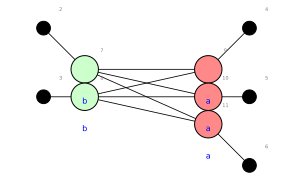

In [9]:
zx.draw_matplotlib(h, labels=True, figsize=(5, 3))

In [10]:
check_all_assignments(h_before, h, ['a', 'b'])

  {'a': 0, 'b': 0}: equal
  {'a': 0, 'b': 1}: equal
  {'a': 1, 'b': 0}: equal
  {'a': 1, 'b': 1}: equal


### On a circuit: a measurement-controlled $X$ through a CNOT

Measure an ancilla to get a random bit, apply $X$ to the control of a CNOT when it is 1. In the diagram the correction is an $X(c[0]\pi)$ spider sitting on the CNOT's control; bialgebra between it and the control spider is the familiar fact that an $X$ on the control propagates to *both* outputs — now with the outcome as a parameter.

In [11]:
circ2 = zx.qasm("""
OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
creg c[1];
h q[2];
measure q[2] -> c[0];
if (c==1) x q[0];
cx q[0],q[1];
""")
k = circ2.to_graph()
k_before = k.copy()
zx.draw(k, labels=True)

In [12]:
x_corr = next(v for v in k.vertices() if k.type(v) == VertexType.X and k.qubit(v) == 0 and isinstance(k.phase(v), Poly))
ctrl = next(u for u in k.neighbors(x_corr) if k.type(u) == VertexType.Z)
print(f"X({k.phase(x_corr)}π) correction: {x_corr}   CNOT control: {ctrl}   check:", check_bialgebra(k, x_corr, ctrl))

bialgebra(k, x_corr, ctrl)
# simplify.spider_simp(k)      # fuse the X(c[0]π) copy into the CNOT target
print("phases:", {v: k.phase(v) for v in k.vertices() if k.phase(v) != 0})
# zx.draw_matplotlib(k, labels=True, figsize=(8, 3))
zx.draw(k, labels=True)

X(c[0]π) correction: 7   CNOT control: 9   check: True
phases: {6: Poly(c[0]), 14: Poly(c[0]), 15: Poly(c[0])}


In [13]:
check_all_assignments(k_before, k, ['c[0]'])

  {'c[0]': 0}: equal
  {'c[0]': 1}: equal


### Not yet parameter-aware: the reverse direction

`simplify.bialg_op_simp` undoes the bialgebra rule on a complete bipartite $Z$–$X$ graph, but its matcher still requires every spider to be phase-free, so it does not recognise the parametrised output above (nor the concrete-$\pi$ version):

In [14]:
spiders = [v for v in h.vertices() if h.type(v) != VertexType.BOUNDARY]
print("reverse match on the K_{2,3} with phases:", match_bialgebra_op(h, spiders))

reverse match on the K_{2,3} with phases: None
